[-0.00100836 -0.00086007  0.00032624 ... -0.00097871 -0.00091939
 -0.00068213]
Энергия сигнала: 9.777565
RT60 (фактически до -60 дБ): 0.119 с


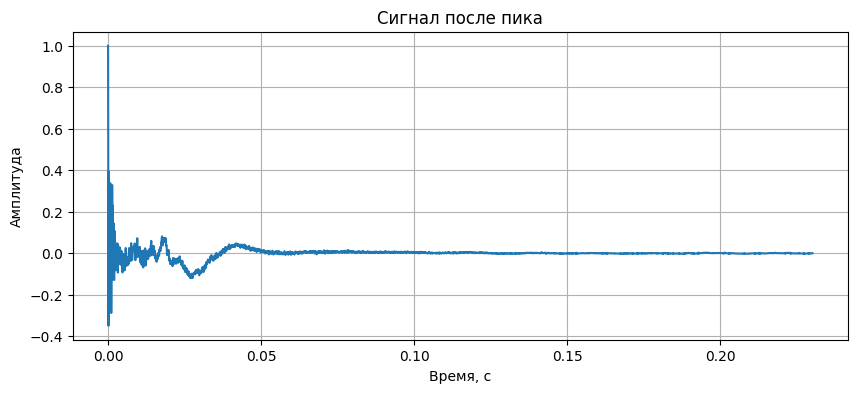

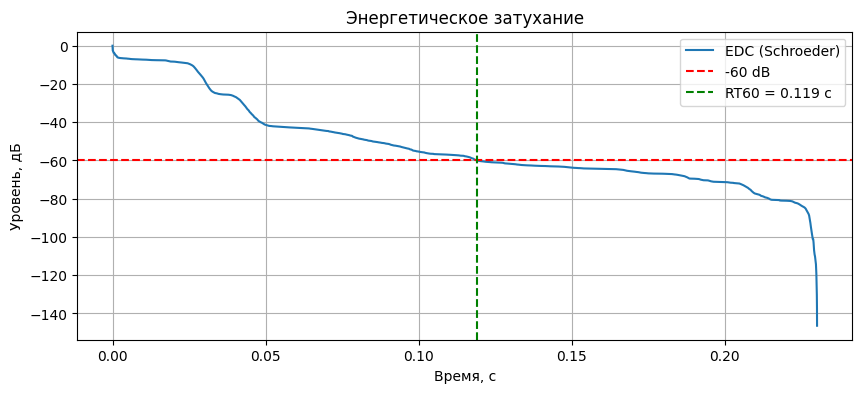

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile

file = "Хлопок.wav"

fs, x = wavfile.read(file)
x = x.astype(float)
if x.ndim > 1:
    x = x.mean(axis=1)
x /= np.max(np.abs(x))
print(x)
# от пика хлопка
i0 = np.argmax(np.abs(x))
x = x[i0:]
t = np.arange(len(x)) / fs

# энергия и кривая Шрёдера
E = np.sum(x**2)
edc = np.cumsum(x[::-1]**2)[::-1]
edc_db = 20 * np.log10(edc / edc[0])

# достижение -60 дБ
idx_60 = np.where(edc_db <= -60)[0]
rt60 = t[idx_60[0]] if len(idx_60) else None

print(f"Энергия сигнала: {E:.6f}")
if rt60 is not None:
    print(f"RT60 (до -60 дБ): {rt60:.3f} с")
else:
    print("Уровень -60 дБ не достигнут в пределах записи")

plt.figure(figsize=(10,4))
plt.plot(t, x)
plt.title("Сигнал после пика")
plt.xlabel("Время, с")
plt.ylabel("Амплитуда")
plt.grid()

plt.figure(figsize=(10,4))
plt.plot(t, edc_db, label="EDC (Schroeder)")
plt.axhline(-60, color="r", linestyle="--", label="-60 dB")
if rt60 is not None:
    plt.axvline(rt60, color="g", linestyle="--", label=f"RT60 = {rt60:.3f} c")
plt.title("Энергетическое затухание")
plt.xlabel("Время, с")
plt.ylabel("Уровень, дБ")
plt.legend()
plt.grid()
plt.show()